# merge MC steps if needed

In [12]:
import os
import glob
import numpy
import modules.io as io
import modules.misc_func as misc


base_dir          = 'test_sim/corrfunc'
N_values          = numpy.unique(numpy.sort(numpy.array(misc.get_par_value_from_str(glob.glob(os.path.join(base_dir,'N*/')),'N'))))
l_values          = numpy.unique(numpy.sort(numpy.array(misc.get_par_value_from_str(glob.glob(os.path.join(base_dir,f'N{N_values[0]}','*.mat')),'l',float))))


dir_name     = [ os.path.join(base_dir,f'N{N}') for N in N_values ]

data_files   = [ 
    [ io.save_merged_simulation_files((f_list:=[f for f in glob.glob(os.path.join(dn,'*_1MCstep*merged.mat')) if misc.par_value_in_str(f,'l',lval,dtype=float) ])[0].replace('_1MCstep',f'_{len(f_list)}_MERGED_MCstep'),io.merge_simulation_files(f_list,ensure_equal_params=True,verbose=True)) for lval in l_values]
    for dn in dir_name 
    ]

data_files

[['test_sim/corrfunc\\N100\\cp_ring_N100_l3.200000_seq_aval_10_MERGED_MCstep_1_merged.mat',
  'test_sim/corrfunc\\N100\\cp_ring_N100_l3.297848_seq_aval_10_MERGED_MCstep_1_merged.mat',
  'test_sim/corrfunc\\N100\\cp_ring_N100_l3.400000_seq_aval_10_MERGED_MCstep_1_merged.mat'],
 ['test_sim/corrfunc\\N500\\cp_ring_N500_l3.200000_seq_aval_10_MERGED_MCstep_1_merged.mat',
  'test_sim/corrfunc\\N500\\cp_ring_N500_l3.297848_seq_aval_10_MERGED_MCstep_1_merged.mat',
  'test_sim/corrfunc\\N500\\cp_ring_N500_l3.400000_seq_aval_10_MERGED_MCstep_1_merged.mat'],
 ['test_sim/corrfunc\\N1000\\cp_ring_N1000_l3.200000_seq_aval_10_MERGED_MCstep_1_merged.mat',
  'test_sim/corrfunc\\N1000\\cp_ring_N1000_l3.297848_seq_aval_10_MERGED_MCstep_1_merged.mat',
  'test_sim/corrfunc\\N1000\\cp_ring_N1000_l3.400000_seq_aval_10_MERGED_MCstep_1_merged.mat'],
 ['test_sim/corrfunc\\N2560\\cp_ring_N2560_l3.200000_seq_aval_10_MERGED_MCstep_1_merged.mat',
  'test_sim/corrfunc\\N2560\\cp_ring_N2560_l3.297848_seq_aval_10_MERG

In [1]:
import os
import sys
import copy
import glob
import numpy
import scipy.io
import modules.io as io
import matplotlib.pyplot as plt

import modules.misc_func as misc
import modules.correlation as corr
# reloading modules
if corr:
    del corr
    del sys.modules['modules.correlation']
import modules.correlation as corr

from IPython.display import clear_output

base_dir          = 'test_sim/corrfunc'
N_values          = numpy.unique(numpy.sort(numpy.array(misc.get_par_value_from_str(glob.glob(os.path.join(base_dir,'N*/')),'N'))))
l_values          = numpy.unique(numpy.sort(numpy.array(misc.get_par_value_from_str(glob.glob(os.path.join(base_dir,f'N{N_values[0]}','*.mat')),'l',float))))

#config_setting    = 'dtsample=100N 300samples'
#config_setting    = 'dtsample=100N 5000samples'
config_setting    = 'merged MCstep'

if config_setting == 'dtsample=100N 300samples': # this configuration is yielding good correlation function, agreeing with oliveira & dickman
    txt_merged        = 'l_merged' # 'MERGED_MCstep' OR '_1_merged' OR
    convert_to_state  = False
    txt_update        = 'seq'
    save_corr_data    = True
    compress_time     = False
    sites_positioning = corr.PositionType.LINE
    corr_file_suffix  = 'dtsample100N_300samp'
elif config_setting == 'dtsample=100N 5000samples': # this configuration is yielding good correlation function, agreeing with oliveira & dickman
    txt_merged        = '_1_merged'
    convert_to_state  = False
    txt_update        = 'seq'
    save_corr_data    = True
    compress_time     = False # if False, maybe crash due to low memory
    sites_positioning = corr.PositionType.LINE
    corr_file_suffix  = 'dtsample100N_5000samp'
elif config_setting == 'merged MCstep': # this configuration is yielding good correlation function, agreeing with oliveira & dickman
    txt_merged        = 'MERGED_MCstep'
    convert_to_state  = True
    txt_update        = 'seq'
    save_corr_data    = True
    compress_time     = True # if False, maybe crash due to low memory
    sites_positioning = corr.PositionType.LINE
    corr_file_suffix  = 'MCstep_merged'

l_c_theory            = 3.297848
nuperp_theory         = 1.09684
beta_theory           = 0.27649
beta_nuperp_theory    = beta_theory/nuperp_theory

# we want to compare different N values for the network,
# so each dir must contain the data files for each N
dir_name     = [ os.path.join(base_dir,f'N{N}') for N in N_values ]

get_lvalues_txt_for_save = lambda l_values: str(list(l_values)).replace(', ','_')[1:-1]
compress_time_str        = '_compressedtime' if compress_time else ''
get_corr_file_name       = lambda N,l_values: f'corr_data_N{N}_lvalues_{get_lvalues_txt_for_save(l_values)}_pos{sites_positioning.name}{compress_time_str}_{corr_file_suffix}.mat'

# selecting data files according to the l_values
data_files   = [ 
    sorted(
    [f for f in glob.glob(os.path.join(dn,'*')) if ( misc.par_value_in_str(f,'l',l_values,dtype=float) and misc.txt_in_str(f,[txt_update,txt_merged]) ) ], 
    key=lambda fname:misc.get_par_value_from_str(fname,'l',float)
    ) for dn in dir_name 
    ]


# output data variables
C_data                 = [ misc.get_empty_list(len(ll)) for ll in data_files ]
lmbda_data             = [ misc.get_empty_list(len(ll)) for ll in data_files ]
lmbda_dispersion_data  = [ misc.get_empty_list(len(ll)) for ll in data_files ]
eigenvectors_data      = [ misc.get_empty_list(len(ll)) for ll in data_files ]
V_matrix_data          = [ misc.get_empty_list(len(ll)) for ll in data_files ]
s_data                 = [ misc.get_empty_list(len(ll)) for ll in data_files ]
Cf_data                = [ misc.get_empty_list(len(ll)) for ll in data_files ]
Cf_std_data            = [ misc.get_empty_list(len(ll)) for ll in data_files ]
d_info                 = [ misc.get_empty_list(len(ll)) for ll in data_files ]

for n,(f_list,N) in enumerate(zip(data_files,N_values)):
    print( '-------------------------------')
    print(f'N = {N}   ({n}/{len(N_values)}; {100*n//len(N_values)}%)')
    for k,f in enumerate(f_list):
        print('* Importing file ... ', f)
        d = io.import_mat_file(f)
        print('* Calculating spike trains ... ')
        #S = corr.spike_times_to_spiketrain(d.X_time/d.dt,d.X_ind,X=d.X_values,N=d.N,convert_act_deact_events_to_site_state=False,compress_time=False)
        S = corr.spike_times_to_spiketrain(d.X_time,d.X_ind,X=d.X_values,N=d.N,convert_act_deact_events_to_site_state=convert_to_state,compress_time=compress_time)
        print('* Calculating correlations ... ')
        C = corr.calc_correlation_matrices(S,smooth=corr.SmoothingType.NONE,binarize=False,nandiag=False,filterSpkFreq=corr.FilterType.NONE,rowvar=True)[0]
        print('* Calculating eigenvalues ... ')
        lmbda,lmbda_dispersion,eigenvectors,V_matrix =  corr.calc_dispersion_PCA(C)
        print('* Calculating correlation function ... ')
        s,Cf,Cf_std = corr.calc_correlation_function_1d_periodicBC(C,avg_same_distance=True,position=sites_positioning)
        d.RemoveFields('X_ind','X_time','X_values')
        C_data[n][k]                = C
        lmbda_data[n][k]            = lmbda
        lmbda_dispersion_data[n][k] = lmbda_dispersion
        eigenvectors_data[n][k]     = eigenvectors
        V_matrix_data[n][k]         = V_matrix
        s_data[n][k]                = s
        Cf_data[n][k]               = Cf
        Cf_std_data[n][k]           = Cf_std
        d_info[n][k]                = copy.deepcopy(d)
        print('-')

    if save_corr_data:
        l_val_txt = get_lvalues_txt_for_save(l_values)
        save_file = os.path.join(base_dir,get_corr_file_name(N,l_values))
        print('* Saving correlation data ... ', save_file)
        corr.save_correlation_data(save_file,C_data[n],lmbda_data[n],lmbda_dispersion_data[n],eigenvectors_data[n],V_matrix_data[n],s_data[n],Cf_data[n],Cf_std_data[n],d_info[n])
    
    clear_output(wait=True)


-------------------------------
N = 5000   (4/5; 80%)
* Importing file ...  test_sim/corrfunc\N5000\cp_ring_N5000_l3.200000_seq_aval_10_MERGED_MCstep_1_merged.mat
* Calculating spike trains ... 
 ::: WARNING ::: Converting spike times to integers... If this is not desired, please convert them before calling, e.g., using t/dt
* Calculating correlations ... 
* Calculating eigenvalues ... 
* Calculating correlation function ... 
-
* Importing file ...  test_sim/corrfunc\N5000\cp_ring_N5000_l3.297848_seq_aval_10_MERGED_MCstep_1_merged.mat
* Calculating spike trains ... 
 ::: WARNING ::: Converting spike times to integers... If this is not desired, please convert them before calling, e.g., using t/dt
* Calculating correlations ... 
* Calculating eigenvalues ... 
* Calculating correlation function ... 
-
* Importing file ...  test_sim/corrfunc\N5000\cp_ring_N5000_l3.400000_seq_aval_10_MERGED_MCstep_1_merged.mat
* Calculating spike trains ... 
 ::: WARNING ::: Converting spike times to intege

# Ring Network Periodic BC

d:\Dropbox\p\uottawa\programs\python\contact_process\modules\misc_func.py:366: RuntimeWarning: invalid value encountered in log
  y_lin = y_transform(y_data[mask])
d:\Dropbox\p\uottawa\programs\python\contact_process\modules\misc_func.py:361: RuntimeWarning: divide by zero encountered in log
  func  = lambda x,*fitpar: y_inverse_transform(fitpar[0] * x_transform(x) + fitpar[1])
d:\Dropbox\p\uottawa\programs\python\contact_process\modules\misc_func.py:385: RuntimeWarning: invalid value encountered in sqrt
  r_value   = numpy.sqrt(1 - ss_res / ss_tot) if ss_tot > 0 else numpy.nan


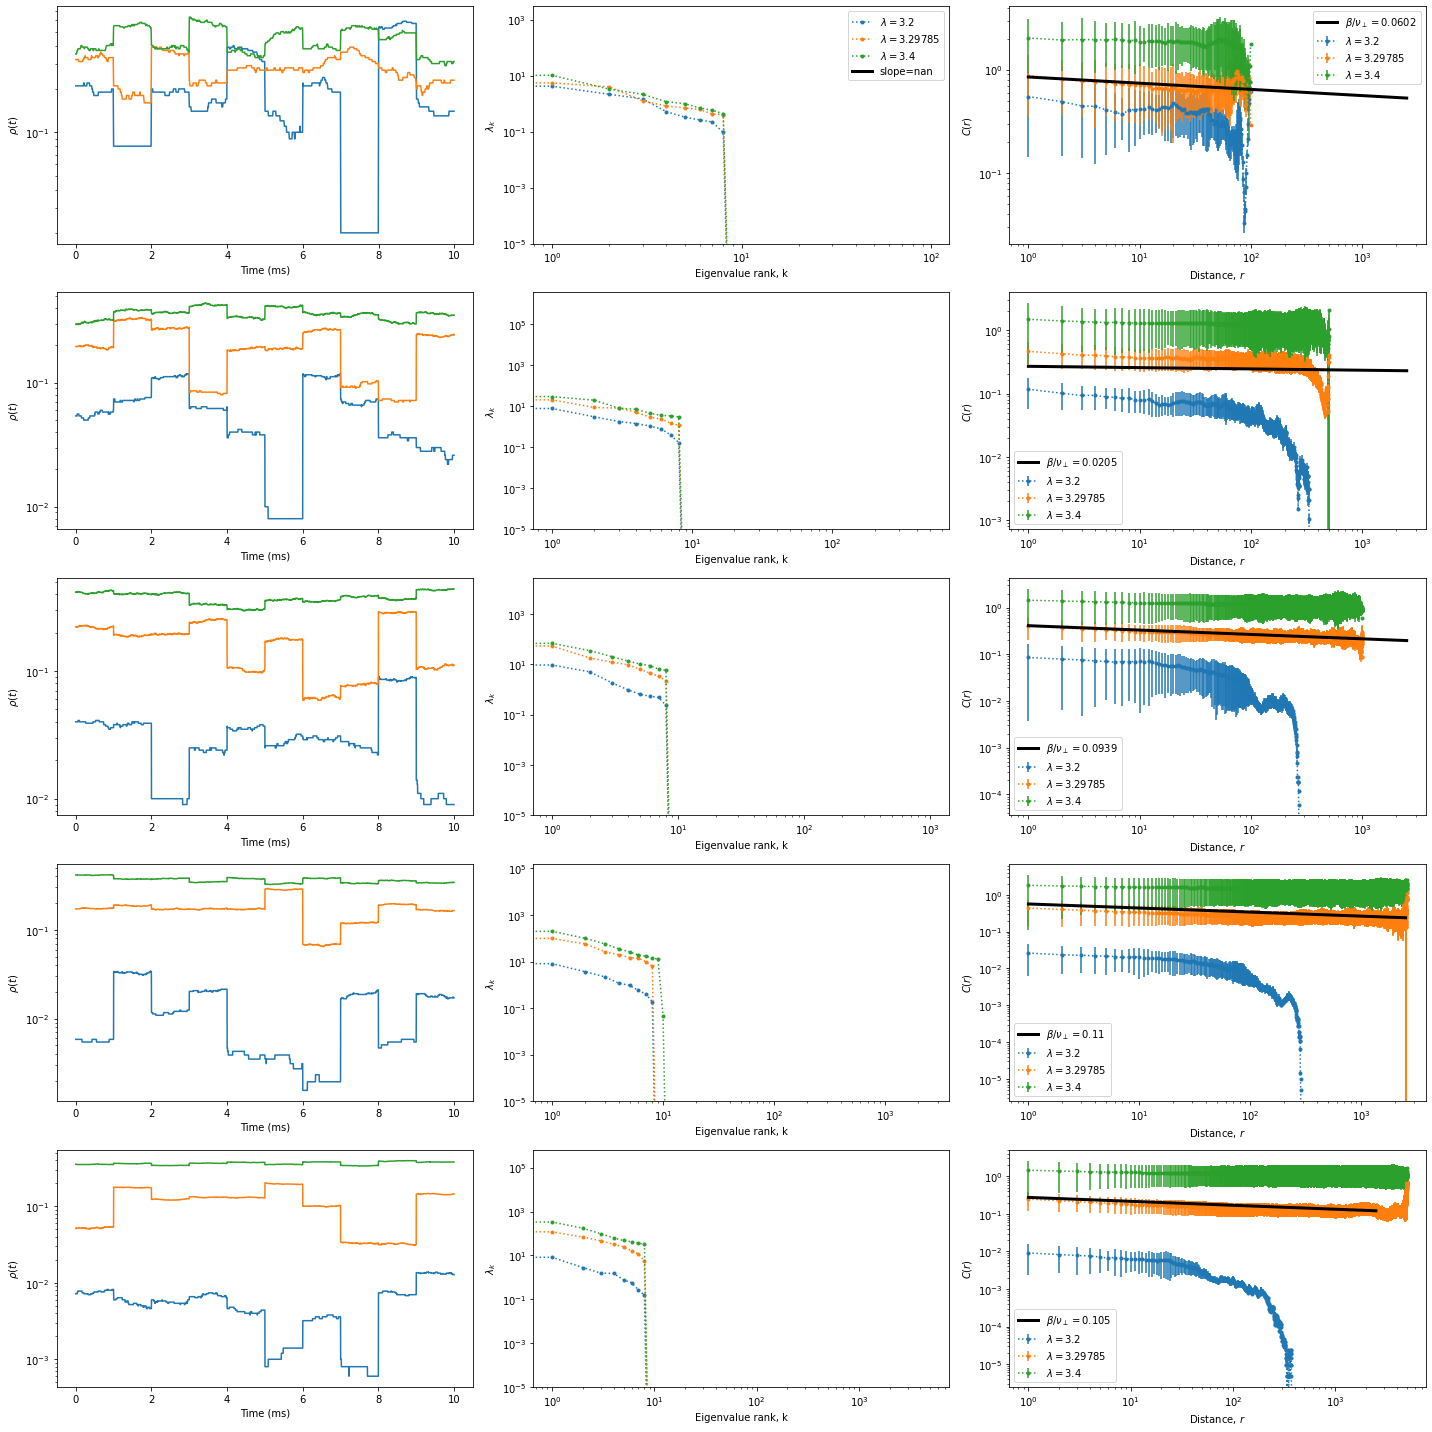

In [2]:
if corr:
    del corr
    del sys.modules['modules.correlation']
import modules.correlation as corr
if misc:
    del misc
    del sys.modules['modules.misc_func']
import modules.misc_func as misc

plt.rcParams.update({'font.size':14})


def _load_data_if_needed(N,l_values,C_data, lmbda_data, lmbda_dispersion_data, eigenvectors_data, V_matrix_data, s_data, Cf_data, Cf_std_data, d_info,exit_script=False):
    corr_data_file = os.path.join(base_dir,get_corr_file_name(N,l_values))
    if os.path.isfile(corr_data_file):
        if (len(C_data)==0):
            print(' * Loading correlation data from file ... ', corr_data_file)
            return corr.load_correlation_data(corr_data_file,split_variables=True)
    else:
        if (len(C_data)==0):
            msg = f' * Data for N={N} not processed... Re-run the first cell.'
            if exit_script:
                raise SystemExit(msg)
            else:
                print('::: WARNING :::', msg)
    return C_data, lmbda_data, lmbda_dispersion_data, eigenvectors_data, V_matrix_data, s_data, Cf_data, Cf_std_data, d_info


def calc_asymptotic_slope(n_points_local_slope,n_points_mean_slope,**linearized_fit_local_args):
    Cf_fit,_   = misc.linearized_fit_local(n_points_local_slope,**linearized_fit_local_args)
    slope      = numpy.array([fr.fitpar[0] for fr in Cf_fit])
    slope_mean = numpy.nanmean(slope[:n_points_mean_slope])
    slope_err  = numpy.nanstd(slope[:n_points_mean_slope]) / numpy.sqrt(n_points_mean_slope)
    return slope_mean,slope_err

n_rows   = len(N_values)
lc_ind   = numpy.argmin(numpy.abs(l_values - l_c_theory))
n_points = 30

fig,ax = plt.subplots(nrows=n_rows,ncols=3,figsize=(20,20))

for n in range(n_rows):
    C_data[n], lmbda_data[n], lmbda_dispersion_data[n], eigenvectors_data[n], V_matrix_data[n], s_data[n], Cf_data[n], Cf_std_data[n], d_info[n] = _load_data_if_needed(N,l_values,C_data[n], lmbda_data[n], lmbda_dispersion_data[n], eigenvectors_data[n], V_matrix_data[n], s_data[n], Cf_data[n], Cf_std_data[n], d_info[n])

    lmbda     = lmbda_data[n][lc_ind]
    k         = numpy.arange(lmbda.size) # eigenvalue rank
    lmbda_fit = misc.linearized_fit(k, lmbda, numpy.log, numpy.log, numpy.exp, (k>10) & (k<300))

    s                     = s_data[n][lc_ind]
    Cf                    = Cf_data[n][lc_ind]
    fit_mask              = (s>=1)&(s<=N/2) if sites_positioning == corr.PositionType.LINE else ( (s<=1.0) if sites_positioning == corr.PositionType.RING else None )
    slope_mean,slope_std  = calc_asymptotic_slope(n_points,20,x_data=s,y_data=Cf,x_transform=numpy.log,y_transform=numpy.log,y_inverse_transform=numpy.exp,mask=fit_mask,verbose=False)
    Cf_fit                = misc.linearized_fit(s,Cf,x_transform=numpy.log,y_transform=numpy.log,y_inverse_transform=numpy.exp,mask=fit_mask,slope=slope_mean)




    for k,d in enumerate(d_info[n]):
        lmbda  = numpy.sort(numpy.abs(lmbda_data[n][k]),)[::-1] #* (1.0 if d.l >= 3.0 else 1e1) # rescaling subcritical data for better view
        s      = s_data[n][k]
        Cf     = Cf_data[n][k]    #* (1.0 if d.l >= 3.0 else 5e2) # rescaling subcritical data for better view
        Cf_std = Cf_std_data[n][k]
        ax[n,0].plot(d.time,d.rho,'-',label=f'$\\lambda={d.l:g}$')
        ax[n,1].plot(numpy.arange(lmbda.size),lmbda,':.',label=f'$\\lambda={d.l:g}$')
        ax[n,2].errorbar(s,Cf,Cf_std,fmt=':.',label=f'$\\lambda={d.l:g}$')

        ax[n,0].set_yscale('log')
        ax[n,0].set_xlabel('Time (ms)')
        ax[n,0].set_ylabel('$\\rho(t)$')
        ax[n,1].set_xscale('log')
        ax[n,1].set_yscale('log')
        ax[n,1].set_xlabel('Eigenvalue rank, k')
        ax[n,1].set_ylabel('$\\lambda_k$')
        ax[n,1].set_ylim(bottom=1e-5)
        ax[n,2].set_xscale('log')
        ax[n,2].set_yscale('log')
        ax[n,2].set_xlabel('Distance, $r$')
        ax[n,2].set_ylabel('$C(r)$')

    k_fit = numpy.linspace(4,100,10)
    r_fit = numpy.linspace(1,N/2,10) if sites_positioning == corr.PositionType.LINE else ( numpy.logspace(-3,0,10) if sites_positioning == corr.PositionType.RING else None )
    ax[n,1].plot(k_fit,lmbda_fit.func(k_fit,*lmbda_fit.fitpar),'-k',linewidth=3,zorder=1000,label=f'slope={lmbda_fit.fitpar[0]:.2g}')
    ax[n,2].plot(r_fit,   Cf_fit.func(r_fit,   *Cf_fit.fitpar),'-k',linewidth=3,zorder=1000,label=f'$\\beta/\\nu_\\perp={-Cf_fit.fitpar[0]:.3g}$')
    ax[n,2].legend()

ax[0,1].legend()

#fig.suptitle(f'N={N}')

plt.tight_layout()
plt.show()


In [112]:
n = -2

lc_ind           = 1
n_points         = 30
s                = s_data[n][lc_ind]
Cf               = Cf_data[n][lc_ind]


slope_mean,slope_std   = calc_asymptotic_slope(n_points,20,x_data=s,y_data=Cf,x_transform=numpy.log,y_transform=numpy.log,y_inverse_transform=numpy.exp,mask=(s>=1)&(s<=N/2),verbose=False)

print(slope_mean,slope_std)

0.2518059592348471 0.0016576726353894767


In [ ]:
def calc_asymptotic_slope(n_points_local_slope,n_points_mean_slope,**linearized_fit_local_args):
    Cf_fit,_   = misc.linearized_fit_local(n_points_local_slope,**linearized_fit_local_args)
    slope      = numpy.array([-fr.fitpar[0] for fr in Cf_fit])
    slope_mean = numpy.nanmean(slope[:n_points_mean_slope])
    slope_std  = numpy.nanstd(slope[:n_points_mean_slope])
    return slope_mean,slope_std

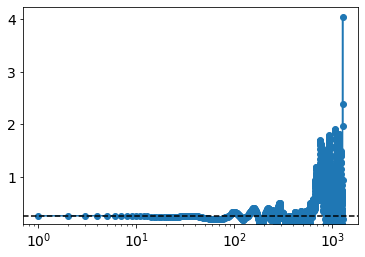

In [103]:
beta_nuperp_local_fit = numpy.array([-fr.fitpar[0] for fr in Cf_fit])
r_local_fit           = numpy.array([ s[k[0]] for k in ind_fit ])
fig,ax = plt.subplots(nrows=1,ncols=1)
ax.plot(r_local_fit,numpy.abs(beta_nuperp_local_fit),'-o')
ax.axhline(beta_nuperp_theory,ls='--',c='k')
ax.set_xscale('log')
#ax.set_yscale('log')
ax.set_ylim(bottom=1e-1)
#ax.set_xlim((0,0.1))
#ax.set_ylim((0.22,0.26))
plt.show()

d:\Dropbox\p\uottawa\programs\python\contact_process\modules\misc_func.py:366: RuntimeWarning: invalid value encountered in log
  y_lin = y_transform(y_data[mask])
d:\Dropbox\p\uottawa\programs\python\contact_process\modules\misc_func.py:361: RuntimeWarning: divide by zero encountered in log
  func  = lambda x,*fitpar: y_inverse_transform(fitpar[0] * x_transform(x) + fitpar[1])


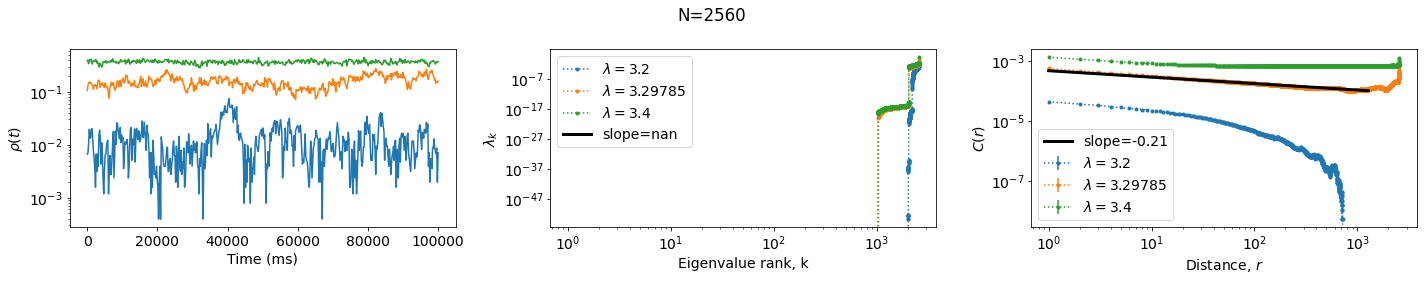

In [111]:
plt.rcParams.update({'font.size':14})

n = -2
N = N_values[n]
if (len(C_data[n])==0) and os.path.isfile(corr_data_file := os.path.join(base_dir,get_corr_file_name(N,l_values))):
    print(' * Loading correlation data from file ... ', corr_data_file)
    C_data[n], lmbda_data[n], lmbda_dispersion_data[n], eigenvectors_data[n], V_matrix_data[n], s_data[n], Cf_data[n], Cf_std_data[n], d_info[n] = corr.load_correlation_data(corr_data_file,split_variables=True)
else:
    if (len(C_data[n])==0):
        raise SystemExit(f' * Data for N={N} not processed... Re-run the first cell.')


if corr:
    del corr
    del sys.modules['modules.correlation']
import modules.correlation as corr
if misc:
    del misc
    del sys.modules['modules.misc_func']
import modules.misc_func as misc


lc_ind    = 1
lmbda     = lmbda_data[n][lc_ind]
k         = numpy.arange(lmbda.size) # eigenvalue rank
lmbda_fit = misc.linearized_fit(k, lmbda, numpy.log, numpy.log, numpy.exp, (k>10) & (k<300))

s       = s_data[n][lc_ind]
Cf      = Cf_data[n][lc_ind]
Cf_fit  = misc.linearized_fit(s,Cf,numpy.log,numpy.log,numpy.exp,(s>=1)&(s<=N/2))


fig,ax = plt.subplots(nrows=1,ncols=3,figsize=(20,4))

for k,d in enumerate(d_info[n]):
    lmbda  = lmbda_data[n][k] * (1.0 if d.l >= 3.0 else 1e1) # rescaling subcritical data for better view
    s      = s_data[n][k]
    Cf     = Cf_data[n][k]    * (1.0 if d.l >= 3.0 else 5e2) # rescaling subcritical data for better view
    Cf_std = Cf_std_data[n][k]
    ax[0].plot(d.time,d.rho,'-',label=f'$\\lambda={d.l:g}$')
    ax[1].plot(numpy.arange(lmbda.size),lmbda,':.',label=f'$\\lambda={d.l:g}$')
    ax[2].errorbar(s,Cf,Cf_std,fmt=':.',label=f'$\\lambda={d.l:g}$')

ax[0].set_yscale('log')
ax[0].set_xlabel('Time (ms)')
ax[0].set_ylabel('$\\rho(t)$')
#ax[1].set_xlim((1.0,1e3))
#ax[1].set_ylim((1e-1,1.5e1))
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlabel('Eigenvalue rank, k')
ax[1].set_ylabel('$\\lambda_k$')
#ax[2].set_xlim((1e-3,1))
#ax[2].set_ylim((2e-3,1.5e-1))
ax[2].set_xscale('log')
ax[2].set_yscale('log')
ax[2].set_xlabel('Distance, $r$')
ax[2].set_ylabel('$C(r)$')

k_fit = numpy.linspace(4,100,10)
r_fit = numpy.linspace(1,N/2,10)
ax[1].plot(k_fit,lmbda_fit.func(k_fit,*lmbda_fit.fitpar),'-k',linewidth=3,zorder=1000,label=f'slope={lmbda_fit.fitpar[0]:.2g}')
ax[2].plot(r_fit,   Cf_fit.func(r_fit,   *Cf_fit.fitpar),'-k',linewidth=3,zorder=1000,label=f'slope={   Cf_fit.fitpar[0]:.2g}')

ax[1].legend()
ax[2].legend()

fig.suptitle(f'N={N}')

plt.tight_layout()
plt.show()


# View time series

 ::: WARNING ::: Converting spike times to integers... If this is not desired, please convert them before calling, e.g., using t/dt


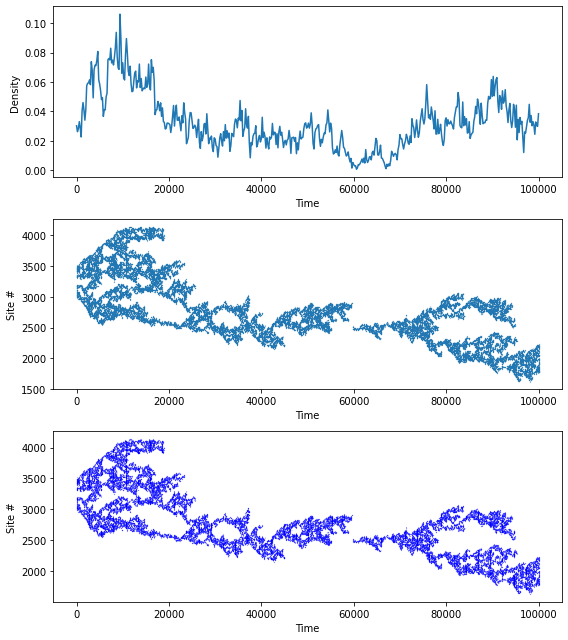

In [26]:
import sys
import modules.io as io
import matplotlib.pyplot as plt

import modules.correlation as corr
# reloading modules
if corr:
    del corr
    del sys.modules['modules.correlation']
import modules.correlation as corr

#d = io.import_mat_file('test_sim/corrfunc/N5000/cp_ring_N5000_l3.200000_seq_aval_merged.mat')
d = io.import_mat_file('test_sim/corrfunc/N5000/cp_ring_N5000_l3.297848_seq_aval_merged.mat')
#d = io.import_mat_file('test_sim/corrfunc/N5000/cp_ring_N5000_l3.400000_seq_aval_merged.mat')

S = corr.spike_times_to_spiketrain(d.X_time,d.X_ind,X=d.X_values,N=d.N)
#C = corr.calc_correlation_matrices()

fig,ax = plt.subplots(nrows=3,ncols=1,figsize=(8,9))

ax[0].plot(d.time,d.rho,'-')
ax[0].set_xlabel('Time')
ax[0].set_ylabel('Density')

ax[1].scatter(d.X_time, d.X_ind, s=0.01)
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Site #')

for k,s in enumerate(S):
    t = numpy.nonzero(s)[0]
    X = s[t]
    if len(t):
        ax[2].plot(t,X+k+1,'.b',markersize=0.1)
ax[2].set_xlabel('Time')
ax[2].set_ylabel('Site #')

plt.tight_layout()

#fig2,ax2 = plt.subplots(nrows=1,ncols=1,figsize=(20,5))
#ax2.imshow(S.T,extent=[0,50000,0,5000])

plt.show()


In [4]:
import gc

plt.close(fig)
plt.close('all')
gc.collect()

52776